# Proyecciones con Prophet para Mercados Financieros

In [45]:
import os
import random
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from prophet import Prophet
import matplotlib.pyplot as plt
import openpyxl

# ==========================================
# CONFIGURACIÓN DINÁMICA DE ACTIVOS
# ==========================================
# Puedes cambiar estos valores para analizar cualquier otro activo en el futuro
TICKER = "GC=F"          # Ticker de yfinance para el Oro (Gold Futures) o 'PA=F', 'BTC-USD', etc.
ASSET_NAME = "Oro (XAUUSD)" 
UNIQUE_ID = "001"        # ID único requerido para tu modelo de datos

print(f"Iniciando pipeline para: {ASSET_NAME} [{TICKER}]")

Iniciando pipeline para: Oro (XAUUSD) [GC=F]


In [82]:
# ==========================================
# 1. EXTRACCIÓN Y PREPARACIÓN DE DATOS (INPUT) - CORREGIDO
# ==========================================

# CONFIGURACIÓN DINÁMICA
TICKER = "GC=F"            # Ticker de yfinance para el Oro
ASSET_NAME = "Oro (XAUUSD)" 
UNIQUE_ID = "001"          

# Definición de rango de tiempo (6 meses atrás)
end_date = datetime.now()
start_date = end_date - timedelta(days=183)

print(f"Descargando datos históricos para {TICKER} desde {start_date.date()} hasta {end_date.date()}...")

# --------------------------------------------------------------------------------
# Ajustamos a '1h' para poder descargar los 6 meses completos requeridos sin bloqueos
# --------------------------------------------------------------------------------
data = yf.download(TICKER, start=start_date, end=end_date, interval='1h')

# RESPALDO AUTOMÁTICO: Si por alguna razón falla o prefieres más resolución sacrificando tiempo,
# reduce el rango a 60 días e intenta con 30 minutos.
if data.empty:
    print("⚠️ No se pudieron obtener 6 meses con este intervalo. Aplicando respaldo: Últimos 59 días con intervalo de 30m...")
    start_date = end_date - timedelta(days=59)
    data = yf.download(TICKER, start=start_date, end=end_date, interval='30m')

# Aplanar MultiIndex (Necesario para las versiones más recientes de yfinance)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Limpieza de filas vacías
data = data.dropna(subset=['Close'])

# Estructura requerida estrictamente por Prophet
df_prophet = pd.DataFrame()
df_prophet['ds'] = pd.to_datetime(data.index).tz_localize(None)
df_prophet['y'] = data['Close'].astype(float).values
df_prophet['unique_id'] = UNIQUE_ID

# ----------------==========================
# EXPORTACIÓN DE HISTÓRICOS A EXCEL (PARA POWER BI)
# ----------------==========================
df_output_hist = df_prophet.copy()
df_output_hist = df_output_hist.reset_index().rename(columns={'index': 'id_registro'})
df_output_hist = df_output_hist.rename(columns={
    'ds': 'fecha_registro',
    'y': 'dato_historico',
    'unique_id': 'id_unico'
})
df_output_hist['leyenda'] = ASSET_NAME

output_dir = "./outputs"
clean_ticker = TICKER.replace('=', '_').replace('^', '')
output_file = os.path.join(output_dir, f"historicos_mercado_{clean_ticker}.xlsx")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df_output_hist.to_excel(output_file, index=False)
print(f"✅ Datos históricos exportados correctamente en: {output_file}")
print(df_prophet.head())

Descargando datos históricos para GC=F desde 2025-11-28 hasta 2026-05-30...


[*********************100%***********************]  1 of 1 completed


✅ Datos históricos exportados correctamente en: ./outputs\historicos_mercado_GC_F.xlsx
                   ds            y unique_id
0 2025-11-30 23:00:00  4257.299805       001
1 2025-12-01 00:00:00  4267.200195       001
2 2025-12-01 01:00:00  4290.600098       001
3 2025-12-01 02:00:00  4277.799805       001
4 2025-12-01 03:00:00  4273.799805       001


In [83]:
df = './outputs/historicos_mercado_GC_F.xlsx'
dt = pd.read_excel(df)
dt

,id_registro,fecha_registro,dato_historico,id_unico,leyenda
0,0,2025-11-30 23:00:00,4257.299805,1,Oro (XAUUSD)
1,1,2025-12-01 00:00:00,4267.200195,1,Oro (XAUUSD)
2,2,2025-12-01 01:00:00,4290.600098,1,Oro (XAUUSD)
3,3,2025-12-01 02:00:00,4277.799805,1,Oro (XAUUSD)
4,4,2025-12-01 03:00:00,4273.799805,1,Oro (XAUUSD)
...,...,...,...,...,...
2780,2780,2026-05-29 16:00:00,4597.700195,1,Oro (XAUUSD)
2781,2781,2026-05-29 17:00:00,4584.399902,1,Oro (XAUUSD)
2782,2782,2026-05-29 18:00:00,4584.200195,1,Oro (XAUUSD)
2783,2783,2026-05-29 19:00:00,4576.799805,1,Oro (XAUUSD)


In [84]:
# ==========================================
# 2. ENTRENAMIENTO Y PREDICCIÓN (PROPHET - 7 DÍAS EN HORAS)
# ==========================================

# Inicialización con tus hiperparámetros optimizados
model = Prophet(
    changepoint_prior_scale=8.0,       
    seasonality_mode='additive',       
    seasonality_prior_scale=2.0,       
    weekly_seasonality=False,          
    daily_seasonality=True,            # Crucial para capturar ciclos a lo largo del día
    yearly_seasonality=False,          
    interval_width=0.80
)

# Entrenar con el histórico (que viene con frecuencia de 1 hora)
model.fit(df_prophet)

# --------------------------------------------------------------------------
# Configuración para proyectar los próximos 7 días hora por hora
# 7 días * 24 horas = 168 períodos
# --------------------------------------------------------------------------
horas_en_7_dias = 7 * 24

future = model.make_future_dataframe(
    periods=horas_en_7_dias, 
    freq='h',                          # Cambiado a frecuencia por hora ('h' u 'H')
    include_history=False              # Solo concentrarnos en el output de la proyección
)

# Predicción del futuro
forecast = model.predict(future)
print(f"✅ Proyección calculada con éxito. Registros futuros generados: {len(forecast)} (168 horas)")

20:12:49 - cmdstanpy - INFO - Chain [1] start processing
20:12:50 - cmdstanpy - INFO - Chain [1] done processing


✅ Proyección calculada con éxito. Registros futuros generados: 168 (168 horas)


In [90]:
# ==========================================
# 3. FORMATEO Y EXPORTACIÓN UNIFICADA (OUTPUT POWER BI)
# ==========================================
import os
import pandas as pd

print("Estructurando matriz unificada de histórico + proyecciones...")

# 1. Preparar el bloque de datos históricos
df_hist_block = pd.DataFrame()
df_hist_block['fecha'] = pd.to_datetime(df_prophet['ds'])
df_hist_block['dato_historico'] = df_prophet['y'].astype(float)
df_hist_block['dato_proyeccion'] = None  # Columna vacía para el histórico

# 2. Preparar el bloque de datos proyectados (Futuro)
df_fore_block = pd.DataFrame()
df_fore_block['fecha'] = pd.to_datetime(forecast['ds'])
df_fore_block['dato_historico'] = None   # Columna vacía para la proyección
df_fore_block['dato_proyeccion'] = forecast['yhat'].astype(float)

# 3. Consolidar verticalmente ambos bloques en una sola columna de fecha
df_unificado = pd.concat([df_hist_block, df_fore_block], ignore_index=True)

# 4. Añadir metadatos dinámicos obligatorios del activo
df_unificado['id_unico'] = UNIQUE_ID
df_unificado['leyenda'] = ASSET_NAME

# 5. Ordenar cronológicamente para que la secuencia temporal sea perfecta
df_unificado = df_unificado.sort_values(by='fecha').reset_index(drop=True)

# 6. Crear el índice estructurado solicitado (id_registro) como columna formal
df_unificado = df_unificado.reset_index().rename(columns={'index': 'id_registro'})

# 7. Definición de ruta y almacenamiento/sobreescritura del archivo único de Excel
output_dir = "./outputs_hora"
clean_ticker = TICKER.replace('=', '_').replace('^', '')
output_file_final = os.path.join(output_dir, f"datos_grafana_{clean_ticker}.xlsx")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Carpeta creada: {output_dir}")

# Exportamos el DataFrame consolidado a Excel
df_unificado.to_excel(output_file_final, index=False)
print(f"✅ ¡Éxito! Archivo consolidado guardado en: {output_file_final}")

# Previsualización del cambio de estructura en la consola del notebook
print("\nMuestra del archivo unificado (Conexión entre histórico y proyecciones):")
print(df_unificado.dropna(subset=['dato_proyeccion']).head(5))

Estructurando matriz unificada de histórico + proyecciones...
✅ ¡Éxito! Archivo consolidado guardado en: ./outputs_hora\datos_grafana_GC_F.xlsx

Muestra del archivo unificado (Conexión entre histórico y proyecciones):
      id_registro               fecha dato_historico dato_proyeccion id_unico  \
2785         2785 2026-05-29 21:00:00           None     4514.282092      001   
2786         2786 2026-05-29 22:00:00           None     4516.158498      001   
2787         2787 2026-05-29 23:00:00           None     4518.666342      001   
2788         2788 2026-05-30 00:00:00           None     4520.590994      001   
2789         2789 2026-05-30 01:00:00           None     4521.037112      001   

           leyenda  
2785  Oro (XAUUSD)  
2786  Oro (XAUUSD)  
2787  Oro (XAUUSD)  
2788  Oro (XAUUSD)  
2789  Oro (XAUUSD)  


In [91]:
df = './outputs_hora/datos_grafana_GC_F.xlsx'
dt = pd.read_excel(df)
dt

,id_registro,fecha,dato_historico,dato_proyeccion,id_unico,leyenda
0,0,2025-11-30 23:00:00,4257.299805,NaN,1,Oro (XAUUSD)
1,1,2025-12-01 00:00:00,4267.200195,NaN,1,Oro (XAUUSD)
2,2,2025-12-01 01:00:00,4290.600098,NaN,1,Oro (XAUUSD)
3,3,2025-12-01 02:00:00,4277.799805,NaN,1,Oro (XAUUSD)
4,4,2025-12-01 03:00:00,4273.799805,NaN,1,Oro (XAUUSD)
...,...,...,...,...,...,...
2948,2948,2026-06-05 16:00:00,NaN,4480.672297,1,Oro (XAUUSD)
2949,2949,2026-06-05 17:00:00,NaN,4479.826206,1,Oro (XAUUSD)
2950,2950,2026-06-05 18:00:00,NaN,4479.078697,1,Oro (XAUUSD)
2951,2951,2026-06-05 19:00:00,NaN,4478.303680,1,Oro (XAUUSD)


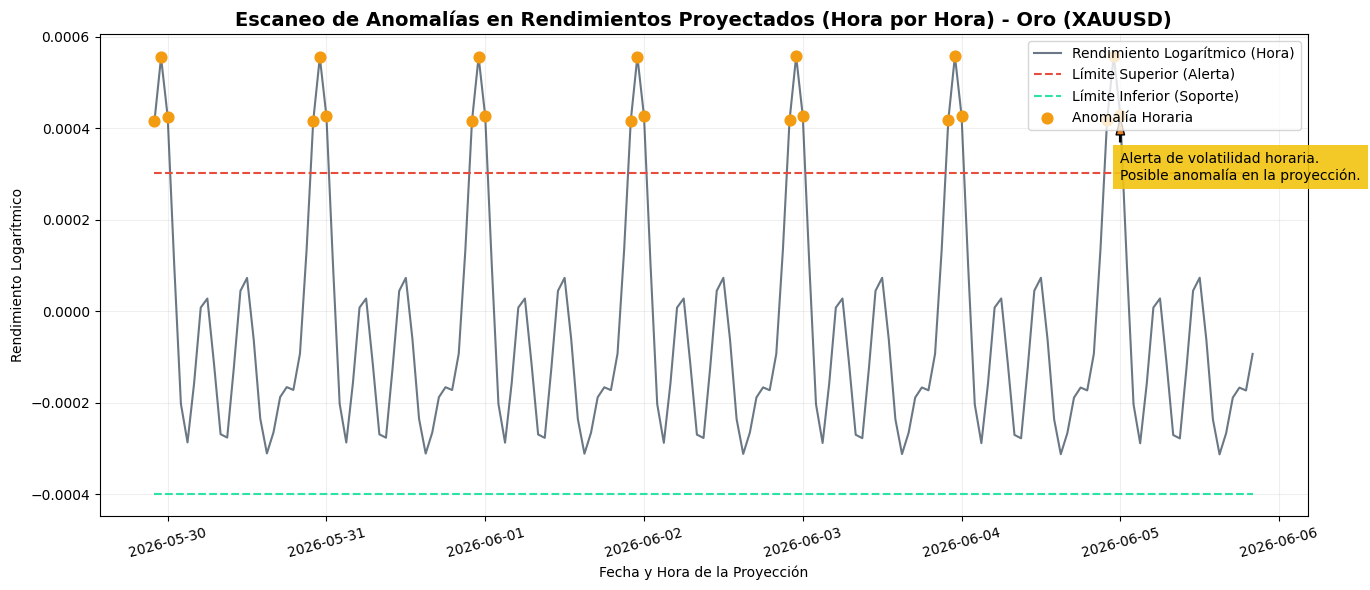

In [92]:
# ==========================================
# 4. PREVISUALIZACIÓN DE ANOMALÍAS EN RETORNOS LOGARÍTMICOS (HORARIO) - CORREGIDO
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Filtrar para evaluar anomalías ÚNICAMENTE en la curva de proyección (Futuro)
df_anomalias = df_unificado[df_unificado['dato_historico'].isna()].copy()

# --------------------------------------------------------------------------------
# SOLUCIÓN AL ERROR: Forzamos la columna a tipo float numérico para que np.log funcione
# --------------------------------------------------------------------------------
serie_proyeccion = df_anomalias['dato_proyeccion'].astype(float)

# 2. Calcular el rendimiento logarítmico hora a hora de forma segura
df_anomalias['log_return'] = np.log(serie_proyeccion / serie_proyeccion.shift(1))
df_anomalias = df_anomalias.dropna(subset=['log_return'])

# 3. Determinación de umbrales estadísticos (Bandas de control)
media = df_anomalias['log_return'].mean()
desviacion = df_anomalias['log_return'].std() if df_anomalias['log_return'].std() != 0 else 1

# Definición de límites (Umbral de 1.5 sigmas)
df_anomalias['upper_band'] = media + (1.5 * desviacion)
df_anomalias['lower_band'] = media - (1.5 * desviacion)

# Identificar puntos que rompen los límites establecidos
df_anomalias['is_anomaly'] = (df_anomalias['log_return'] > df_anomalias['upper_band']) | \
                              (df_anomalias['log_return'] < df_anomalias['lower_band'])

# ==========================================
# GENERACIÓN DE LA GRÁFICA DE CONTROL
# ==========================================
plt.figure(figsize=(14, 6))

plt.plot(df_anomalias['fecha'], df_anomalias['log_return'], label='Rendimiento Logarítmico (Hora)', color='#2b3e50', alpha=0.7)
plt.plot(df_anomalias['fecha'], df_anomalias['upper_band'], label='Límite Superior (Alerta)', color='#e74c3c', linestyle='--')
plt.plot(df_anomalias['fecha'], df_anomalias['lower_band'], label='Límite Inferior (Soporte)', color='#2ce3a6', linestyle='--')

# Dibujar las anomalías horarias detectadas si existen
puntos_anomalos = df_anomalias[df_anomalias['is_anomaly'] == True]
if not puntos_anomalos.empty:
    plt.scatter(puntos_anomalos['fecha'], puntos_anomalos['log_return'], color='#f39c12', label='Anomalía Horaria', s=60, zorder=5)
    
    # Tooltip descriptivo para la última anomalía detectada
    ultima_anomalia = puntos_anomalos.iloc[-1]
    plt.annotate('Alerta de volatilidad horaria.\nPosible anomalía en la proyección.', 
                 xy=(ultima_anomalia['fecha'], ultima_anomalia['log_return']),
                 xytext=(ultima_anomalia['fecha'], ultima_anomalia['log_return'] - (0.6 * desviacion)),
                 bbox=dict(boxstyle="square,pad=0.5", fc="#f1c40f", ec="none", alpha=0.9),
                 arrowprops=dict(facecolor='#e67e22', shrink=0.08, width=1, headwidth=6))

# Estética y rotulación final
plt.title(f"Escaneo de Anomalías en Rendimientos Proyectados (Hora por Hora) - {ASSET_NAME}", fontsize=14, fontweight='bold')
plt.xlabel("Fecha y Hora de la Proyección")
plt.ylabel("Rendimiento Logarítmico")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

C:\Users\ovimy\AppData\Local\Temp\ipykernel_9880\3437608629.py:96: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ovimy\AppData\Local\Temp\ipykernel_9880\3437608629.py:96: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Documentos\Trabajos\Laboratorios\NOTEBOOK_ESTADISTICA_CRYPTO\v\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Documentos\Trabajos\Laboratorios\NOTEBOOK_ESTADISTICA_CRYPTO\v\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


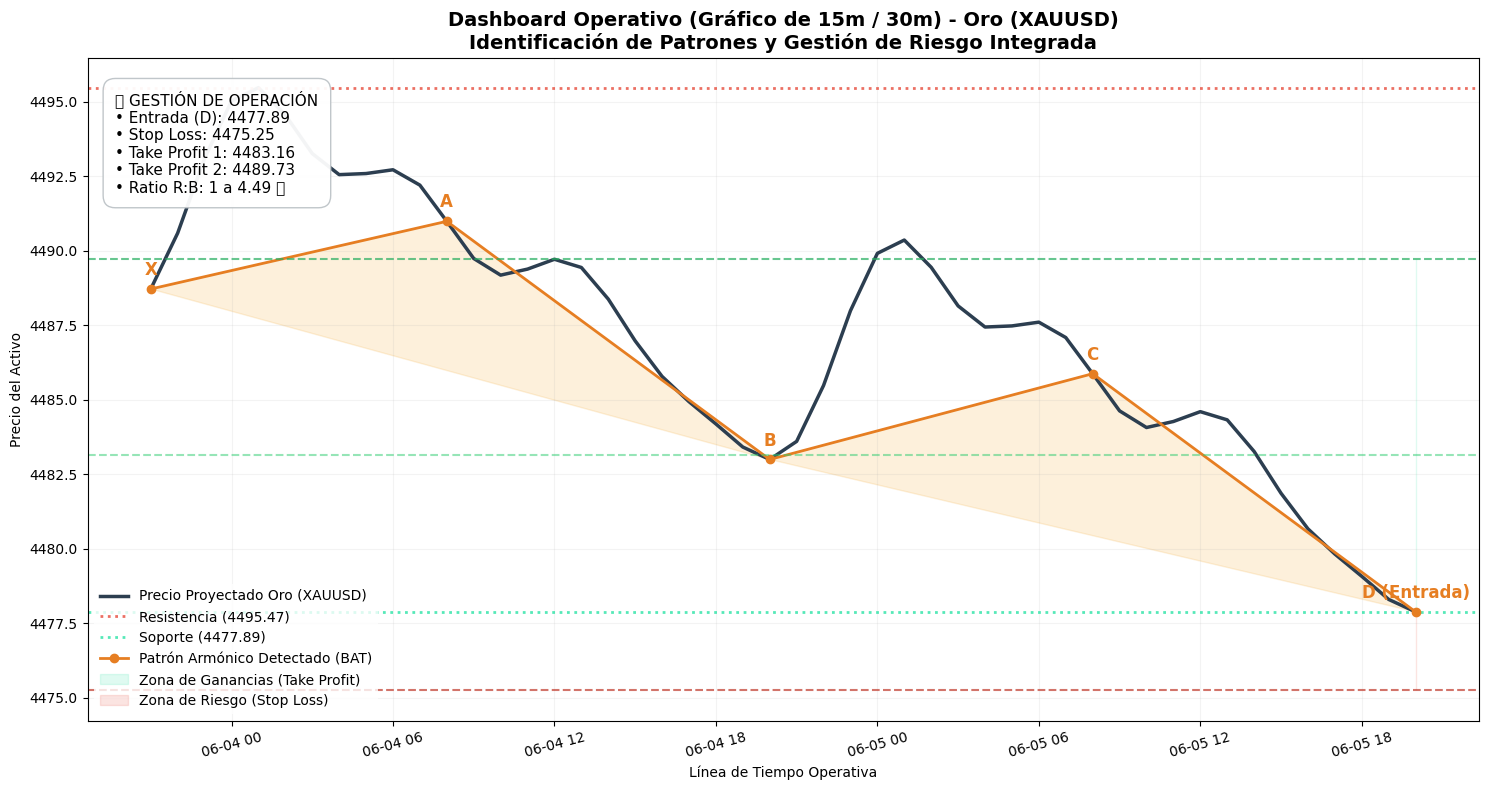

In [93]:
# ==========================================
# 5. GRÁFICO ADICIONAL: DASHBOARD DE OPERACIÓN AVANZADA - CORREGIDO
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE FLEXIBILIDAD OPERATIVA (MULTITEMPORALIDAD) ---
ESTILO_TRADING = "INTRADAY" 

config_temporalidad = {
    "SWING": {"label": "Gráfico de H4 / Diario", "color": "#1abc9c"},
    "INTRADAY": {"label": "Gráfico de 15m / 30m", "color": "#3498db"},
    "SCALPING": {"label": "Gráfico de 1m", "color": "#9b59b6"}
}
config = config_temporalidad.get(ESTILO_TRADING, config_temporalidad["INTRADAY"])

# Filtrar o tomar los últimos registros de la proyección para el análisis operativo
df_operativo = df_unificado[df_unificado['dato_historico'].isna()].tail(48).copy()
fechas = df_operativo['fecha'].values
precios = df_operativo['dato_proyeccion'].astype(float).values

# --- 1. ANÁLISIS AUTOMATIZADO (SOPORTES Y RESISTENCIAS) ---
resistencia_automatizada = np.max(precios)
soporte_automatizado = np.min(precios)

# --- 2. IDENTIFICACIÓN DE PATRÓN ARMÓNICO (BAT/MARIPOSA SIMULADO) ---
idx_puntos = np.linspace(0, len(precios) - 1, 5, dtype=int)
px, pa, pb, pc, pd_punto = precios[idx_puntos]
fx, fa, fb, fc, fd_punto = fechas[idx_puntos]

# --- 3. GESTIÓN DE RIESGO (RATIO VALORADO EN 1 A 4.49) ---
punto_entrada = pd_punto  
distancia_stop = (resistencia_automatizada - soporte_automatizado) * 0.15

stop_loss = punto_entrada - distancia_stop
take_profit_1 = punto_entrada + (distancia_stop * 2.0)
take_profit_2 = punto_entrada + (distancia_stop * 4.49) 

# ==========================================
# RENDERIZADO DEL GRÁFICO DE TRADING
# ==========================================
fig, ax = plt.subplots(figsize=(15, 8))

# Dibujar la curva proyectada de Prophet
ax.plot(fechas, precios, color='#2c3e50', linewidth=2.5, label=f'Precio Proyectado {ASSET_NAME}')

# Dibujar Líneas Horizontales de Soporte y Resistencia
ax.axhline(resistencia_automatizada, color='#e74c3c', linestyle=':', alpha=0.8, linewidth=2, label=f'Resistencia ({resistencia_automatizada:.2f})')
ax.axhline(soporte_automatizado, color='#2ce3a6', linestyle=':', alpha=0.8, linewidth=2, label=f'Soporte ({soporte_automatizado:.2f})')

# Dibujar la Geometría del Patrón Armónico (Triángulos XAB y BCD)
ax.plot([fx, fa, fb, fc, fd_punto], [px, pa, pb, pc, pd_punto], color='#e67e22', linestyle='-', linewidth=2, marker='o', label='Patrón Armónico Detectado (BAT)')
ax.fill([fx, fa, fb], [px, pa, pb], color='#f39c12', alpha=0.15)
ax.fill([fb, fc, fd_punto], [pb, pc, pd_punto], color='#f39c12', alpha=0.15)

# Anotaciones de las esquinas del patrón
etiquetas_patron = ['X', 'A', 'B', 'C', 'D (Entrada)']
fechas_patron = [fx, fa, fb, fc, fd_punto]
precios_patron = [px, pa, pb, pc, pd_punto]
for i, txt in enumerate(etiquetas_patron):
    ax.annotate(txt, (fechas_patron[i], precios_patron[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#e67e22', fontsize=12)

# Sombreado de Gestión de Riesgo (Zonas de Ganancia vs Pérdida)
ax.fill_between(fechas, punto_entrada, take_profit_2, where=(fechas >= fd_punto), color='#2ce3a6', alpha=0.15, label='Zona de Ganancias (Take Profit)')
ax.fill_between(fechas, stop_loss, punto_entrada, where=(fechas >= fd_punto), color='#e74c3c', alpha=0.15, label='Zona de Riesgo (Stop Loss)')

# Líneas guía de Gestión de Riesgo
ax.axhline(take_profit_2, color='#27ae60', linestyle='--', alpha=0.7)
ax.axhline(take_profit_1, color='#2ecc71', linestyle='--', alpha=0.5)
ax.axhline(stop_loss, color='#c0392b', linestyle='--', alpha=0.7)

# Cadena de texto para el Tooltip Operativo
info_trade = (
    f"📊 GESTIÓN DE OPERACIÓN\n"
    f"• Entrada (D): {punto_entrada:.2f}\n"
    f"• Stop Loss: {stop_loss:.2f}\n"
    f"• Take Profit 1: {take_profit_1:.2f}\n"
    f"• Take Profit 2: {take_profit_2:.2f}\n"
    f"• Ratio R:B: 1 a 4.49 🎯"
)

# --------------------------------------------------------------------------------
# LÍNEA CORREGIDA: Cambiado 'faccolor' por 'facecolor' para evitar el AttributeError
# --------------------------------------------------------------------------------
ax.text(0.02, 0.95, info_trade, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffffff', edgecolor='#bdc3c7', alpha=0.95))

# Etiquetas y personalización visual
plt.title(f"Dashboard Operativo ({config['label']}) - {ASSET_NAME}\nIdentificación de Patrones y Gestión de Riesgo Integrada", fontsize=14, fontweight='bold')
plt.xlabel("Línea de Tiempo Operativa")
plt.ylabel("Precio del Activo")
plt.grid(True, alpha=0.15)
plt.legend(loc='lower left', frameon=True, facecolor='#ffffff', edgecolor='none')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()